In [1]:
import os
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import lmfit 

from math import factorial

import matplotlib.pyplot as plt

from scipy import optimize

from kineticanalysis.generator.generator_track import (generate_tracks,
                                                        generate_one_track,
                                                        generate_profile)
from kineticanalysis.analysis.analysis_track import (autocorrelation,
                                                    fit_function,
                                                    single_track_analysis,
                                                    fit_autocorrelation_linear,
                                                    fit_autocorrelation_approx)

In [2]:
def generate_one_track(prot_length,
                       suntag_length,
                       nb_suntag,
                       fluo_one_suntag,
                       translation_rate,
                       binding_rate,
                       retention_time=0,
                       suntag_pos="begin",
                       noise=False,
                       noise_std=0,
                       step=0.1,
                       length=6000,
                       ):
    x, y = generate_profile(prot_length,
                            suntag_length,
                            nb_suntag,
                            fluo_one_suntag,
                            translation_rate,
                            retention_time,
                            suntag_pos,
                            step,
                            noise,
                            noise_std
                            )

    # global signal
    x_global = np.arange(length, step=step)
    y_global = np.zeros(len(x_global))
    y_start_prot = np.zeros(len(x_global))

    n_rand = np.random.rand(len(x_global))
    for i in range(len(x_global)):
        # random number between 0 and 1
        if n_rand[i] < (binding_rate * step):
            if i > (len(x_global) - len(x)):
                y_global[i:i + len(x)] += y[:len(y_global[i:i + len(x)])]
                y_start_prot[i:i + len(x)] += 1
            else:
                y_global[i:i + len(x)] += y
                y_start_prot[i:i + len(x)] += 1

    # Remove the first time points
    # x_global = x_global[2000:] - 200  # -200 to start time at 0
    # y_global = y_global[2000:]
    # y_start_prot = y_start_prot[2000:]

    return x_global, y_global, y_start_prot


def autocorrelation_manual(intensity, lags):
    I = np.array(intensity, dtype=float)
    N = len(I)

    # Mean intensity
    I_mean = np.mean(I)
    delta_I = I - I_mean

    # Compute autocorrelation via FFT (efficient method)
    # Pad to 2N for no circular overlap
    f = np.fft.fft(delta_I, n=2*N)
    ac = np.fft.ifft(f * np.conjugate(f))[:N].real

    # Normalize
    ac /= np.arange(N, 0, -1)   # correct for reduced pairs at long τ
    G = ac / (I_mean ** 2)

    # Lag times
    tau = np.arange(N)

    return tau, G


def fit_function_exact(x, k, c, N):
    return (k/c)*(2/3)*(1/((N*(N+1))**2)) * np.exp(-k*x) * (
        sum((N-n)*(N-n+1)*((2*N)+n+1)*(((k*x)**n)/factorial(n)) for n in range (0, int(N)))
    )

# model = lmfit.Model(fit_function_exact)
# params = lmfit.Parameters() 
# params.add('N', value=32, vary=False)
# params.add('k', value=1, min=0)
# params.add('c', value=1, min=0)

# result = model.fit(y_auto3, params, x=np.arange(0,len(y_auto3)))

# result


In [107]:
suntag_length = 796
prot_length = 480
nb_suntag = 32
fluo_one_suntag = 4
translation_rate = 5
binding_rate = 0.33
step = 0.1
length = 6000


x_global, y_global, y_start = generate_one_track(prot_length=prot_length,
                                                   suntag_length=suntag_length,
                                                   nb_suntag=nb_suntag,
                                                   fluo_one_suntag=fluo_one_suntag,
                                                   translation_rate=translation_rate,
                                                   binding_rate=binding_rate,
                                                   step=step,
                                                   length=length)

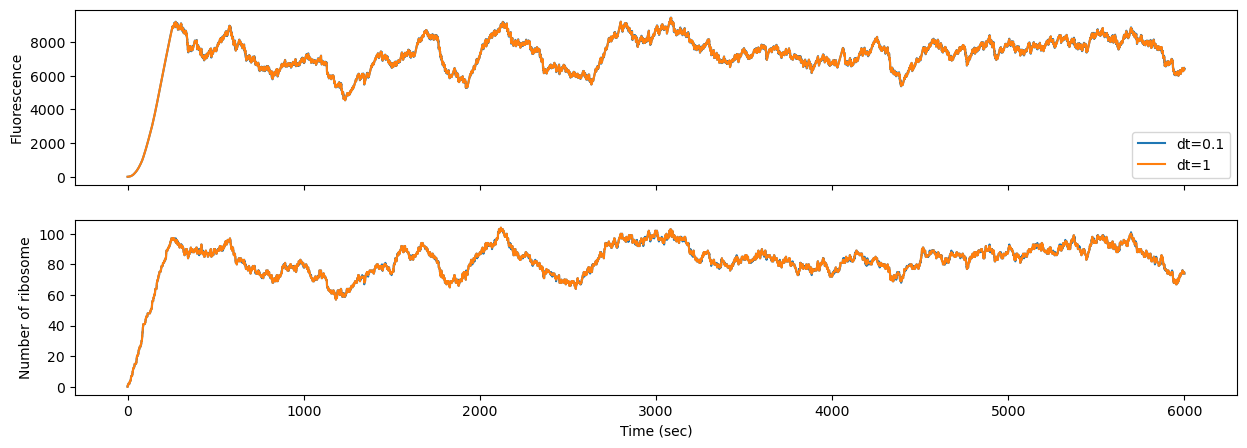

In [108]:
fig, axes = plt.subplots(nrows = 2, sharex=True)
max_ = 60000 # nb_point
step_ = 1
axes[0].plot(x_global[::step_][:max_], y_global[::step_][:max_], label="dt=0.1")
axes[1].plot(x_global[::step_][:max_], y_start[::step_][:max_])

max_ = 6000  # nb point
step_ = 10
axes[0].plot(x_global[::step_][:max_], y_global[::step_][:max_], label="dt=1")
axes[1].plot(x_global[::step_][:max_], y_start[::step_][:max_])

axes[0].legend()
axes[0].set_ylabel("Fluorescence")
axes[1].set_ylabel("Number of ribosome")
axes[1].set_xlabel("Time (sec)")

fig.set_size_inches((15,5))

137 137
2.0400203730756337 0.43244221501463675
55.040552553440335


/tmp/ipykernel_747259/1439448148.py:34: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  datas = pd.concat([datas,


129 129
1.509972062181459 0.4250923229302057
39.98312737586822
70 70
21.307733348092974 0.6803841111817164
548.0067184765167
98 98
4.7382846483888565 0.705021176585237
129.16370398505487
70 70
5.88319900325717 0.7228504897539256
153.48832191655592
84 84
6.902926814519834 0.562033207562791
181.58339190666862
132 132
2.3639629035931833 0.4351130178728393
64.02250313497383
16 72
11.730404741657045 0.39749833672627477
275.730525818779
131 131
0.5815707306928743 0.37861816639670764
16.92067774834909
66 66
11.498527426241838 0.5190674667089421
290.8140955137443
33 65
27.630614889130626 0.6469548095761355
587.5594188461256
79 79
6.388832545340507 0.4694356667185706
163.55798982052414
41 67
18.087597720470207 0.6434071472624838
436.76031080285895
27 27
52.00136672593206 1.228631889464455
1297.6002062120006
25 37
40.79703586217534 0.9449942280183656
927.8282487478732
49 49
19.349994173729677 1.0211065106229098
519.0552802983134
119 119
1.0930564114904104 0.4168161965465538
30.924509226245178
13

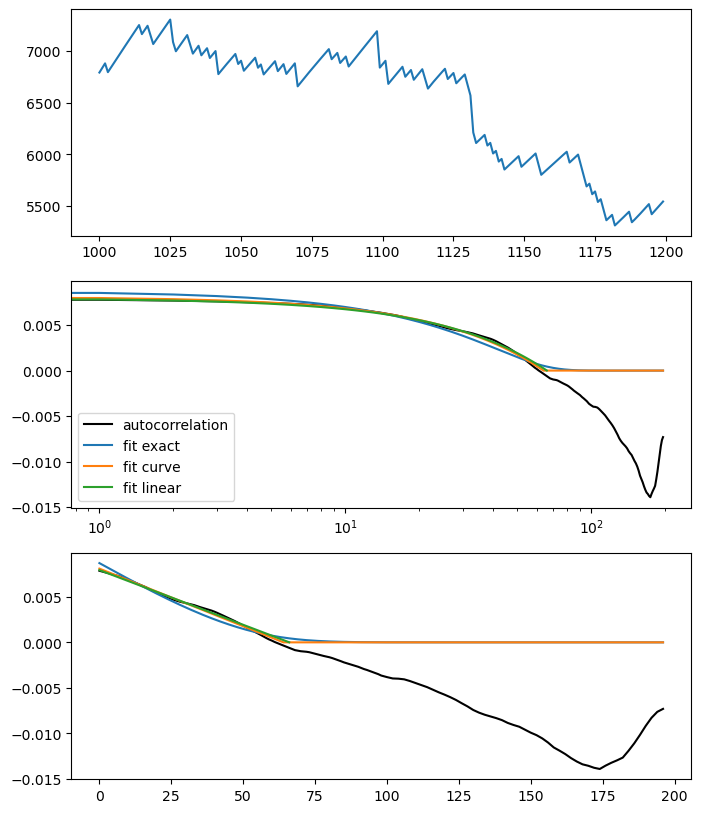

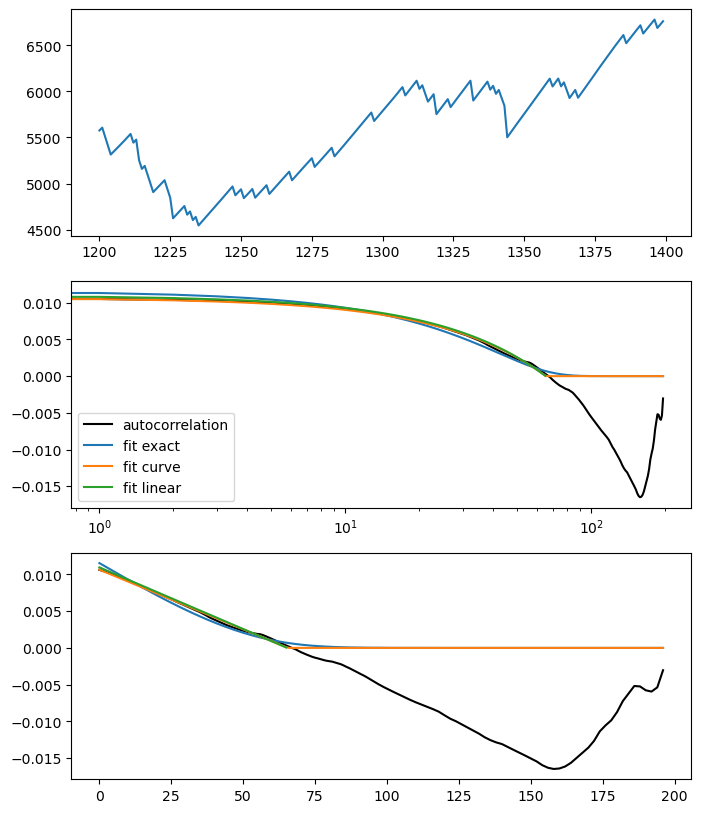

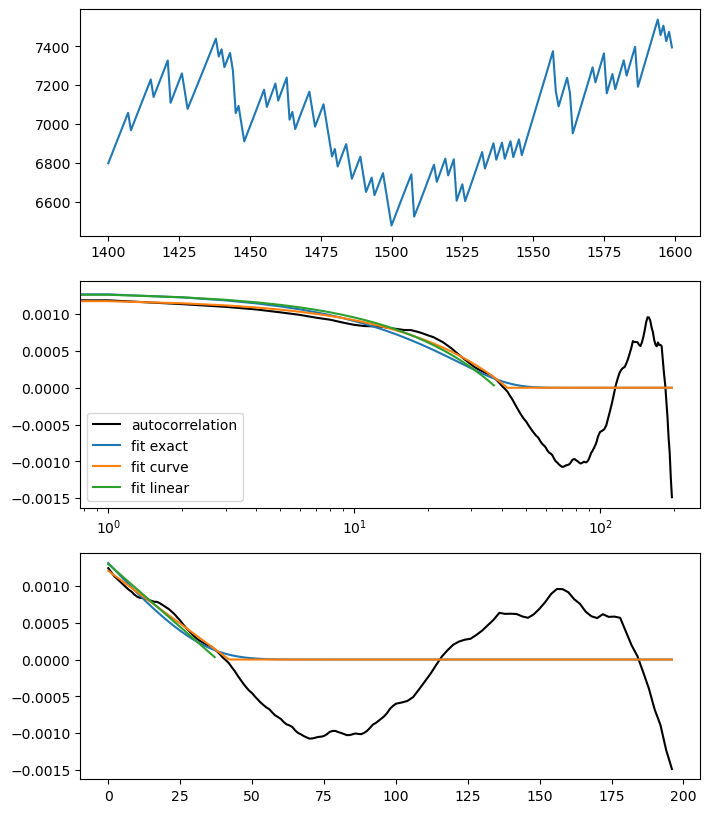

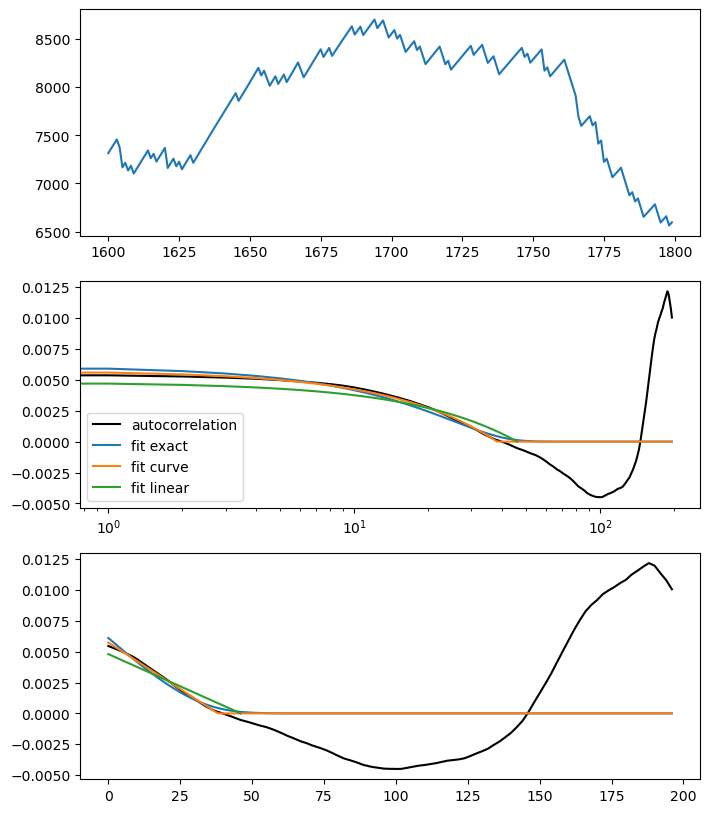

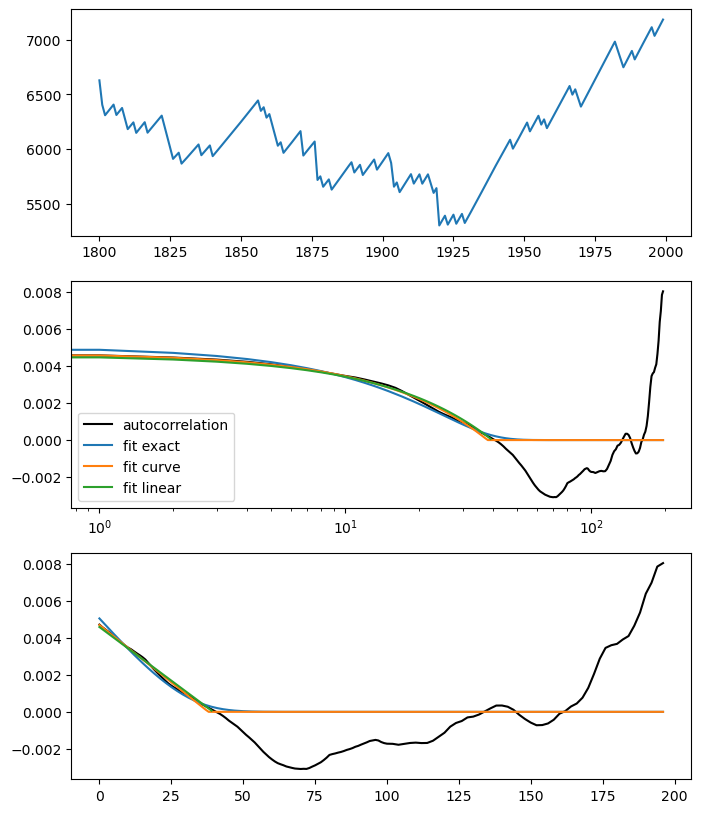

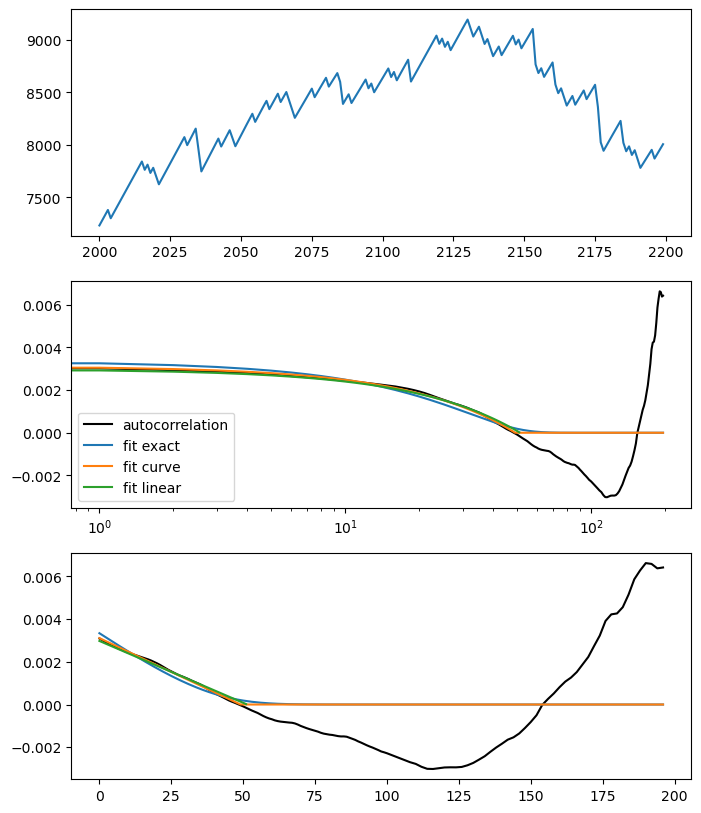

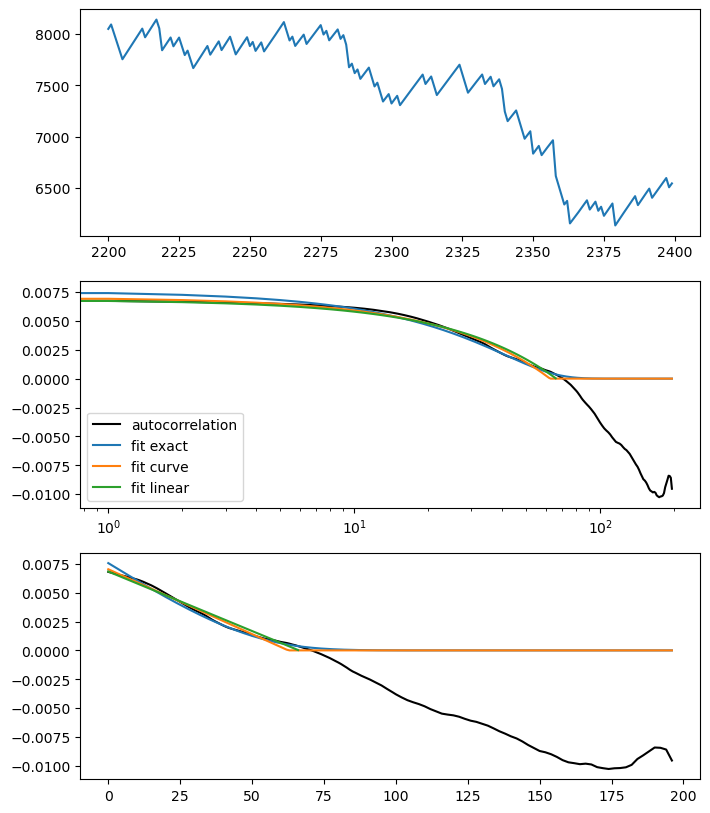

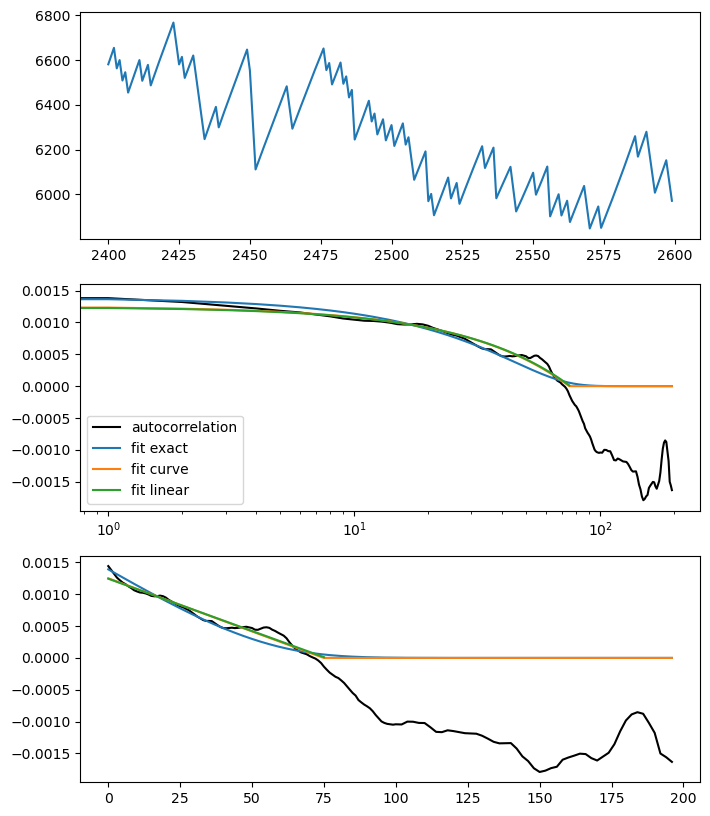

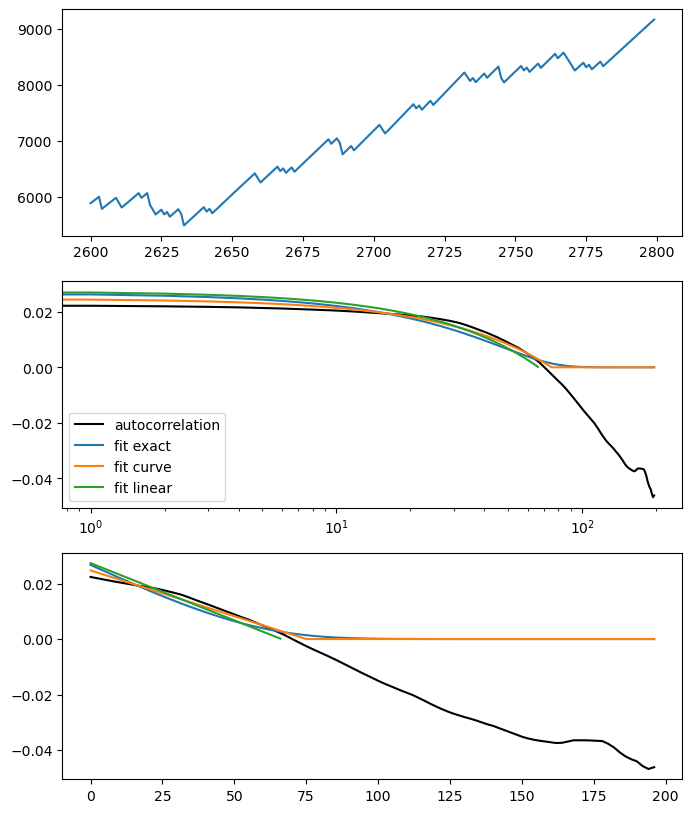

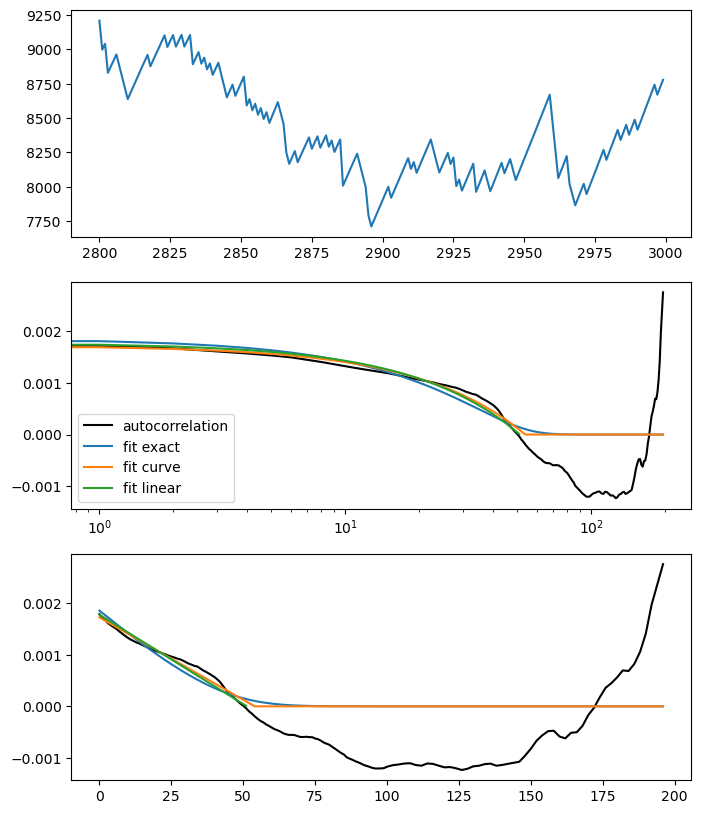

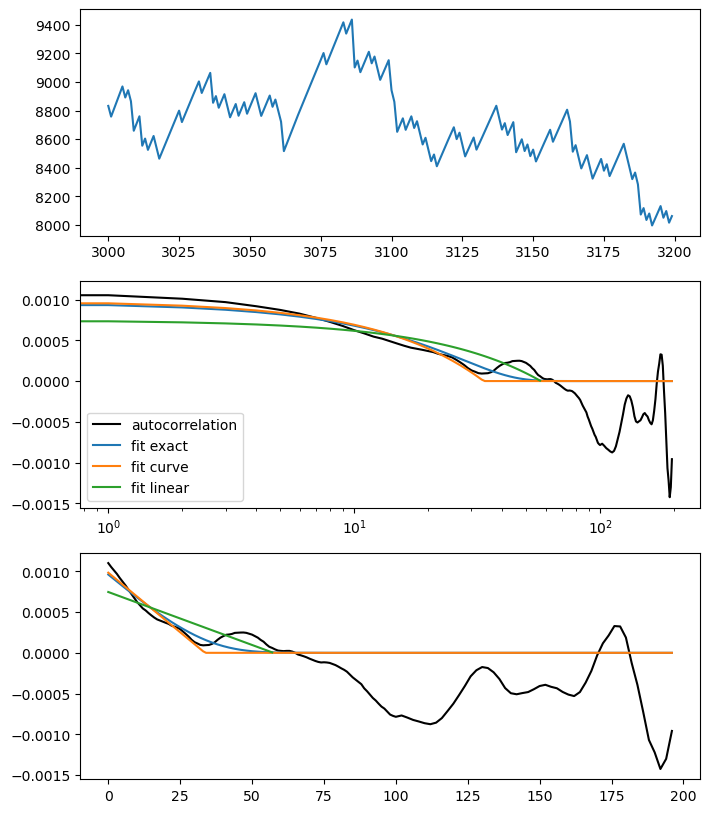

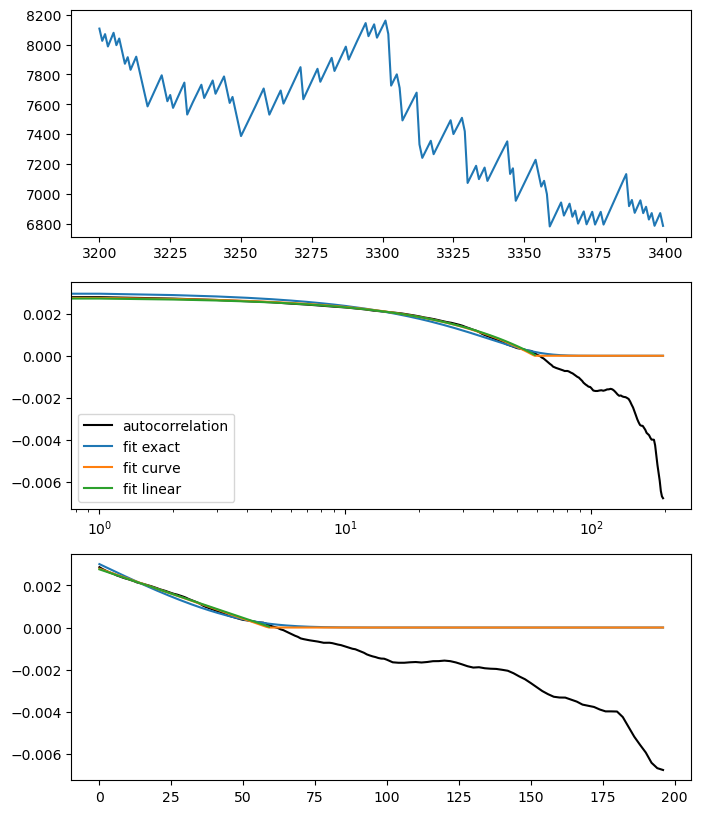

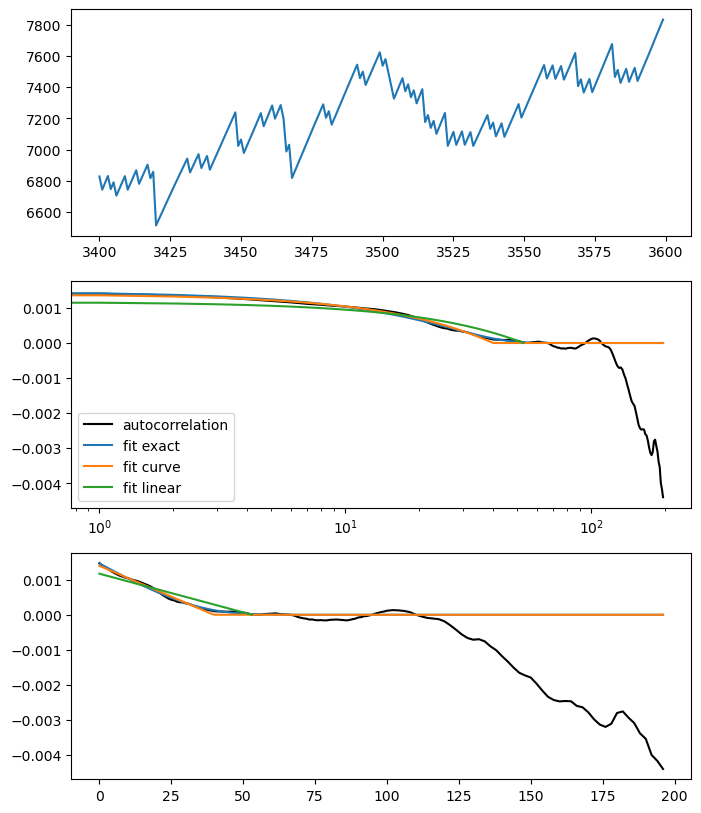

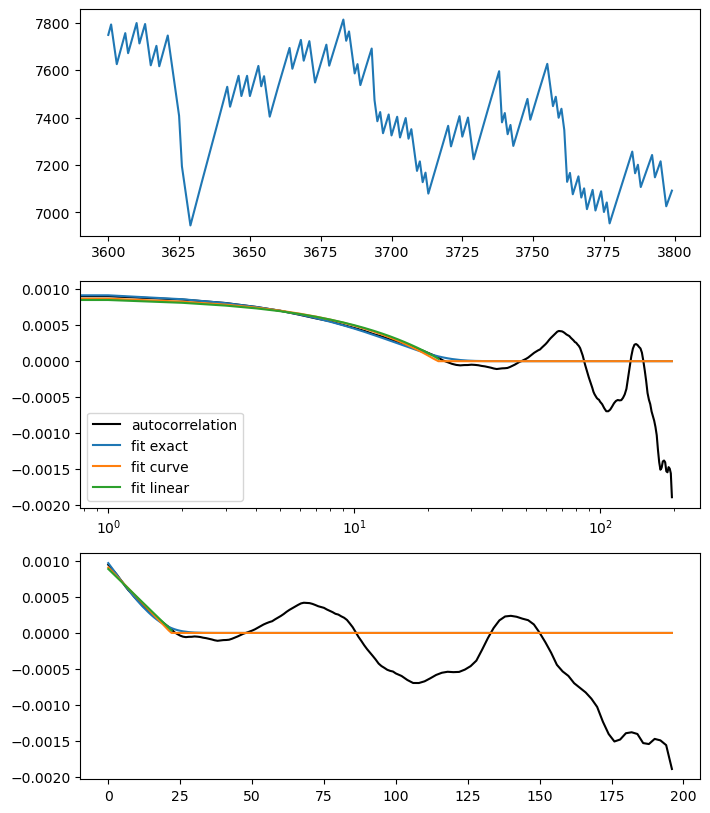

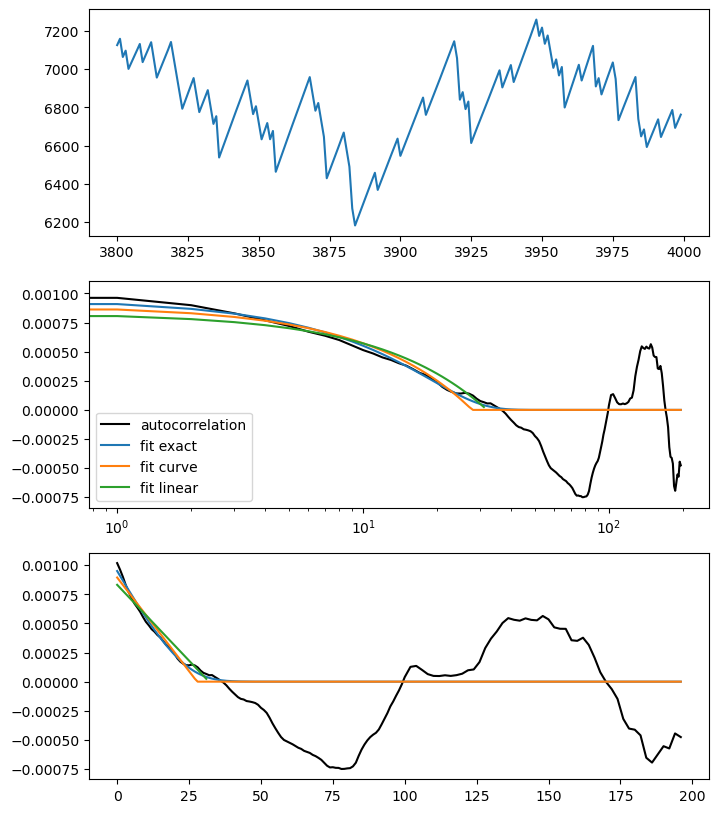

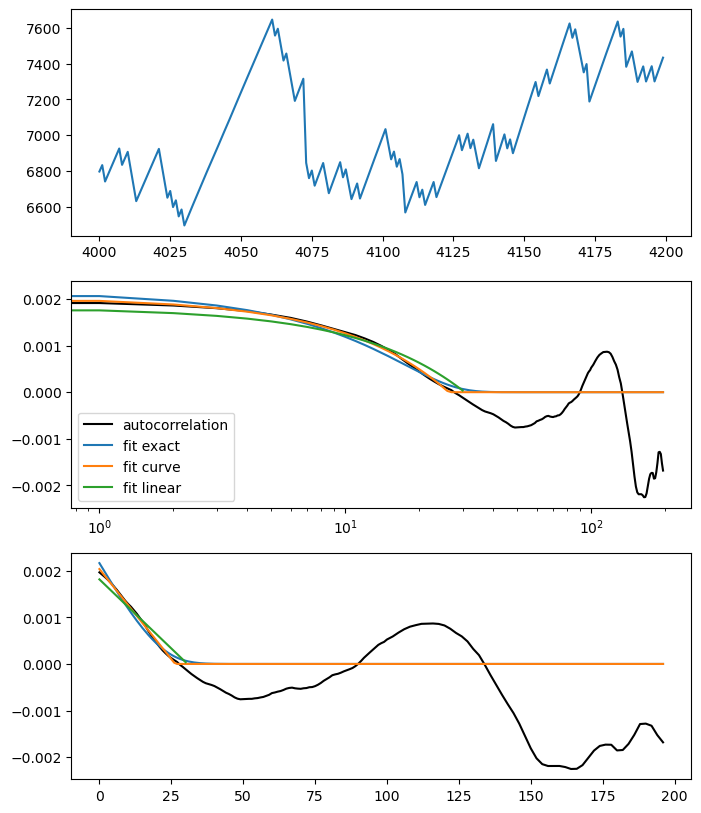

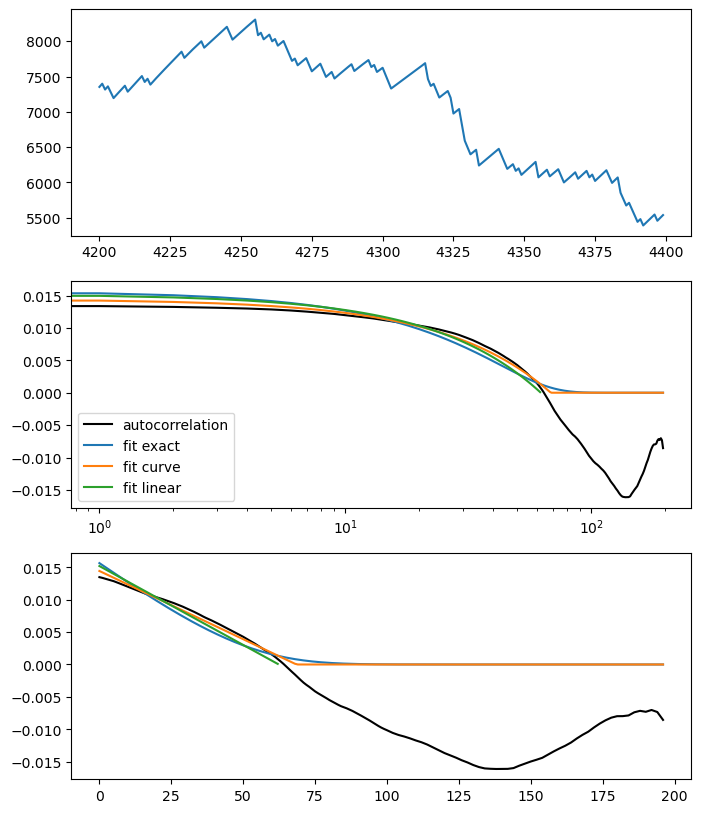

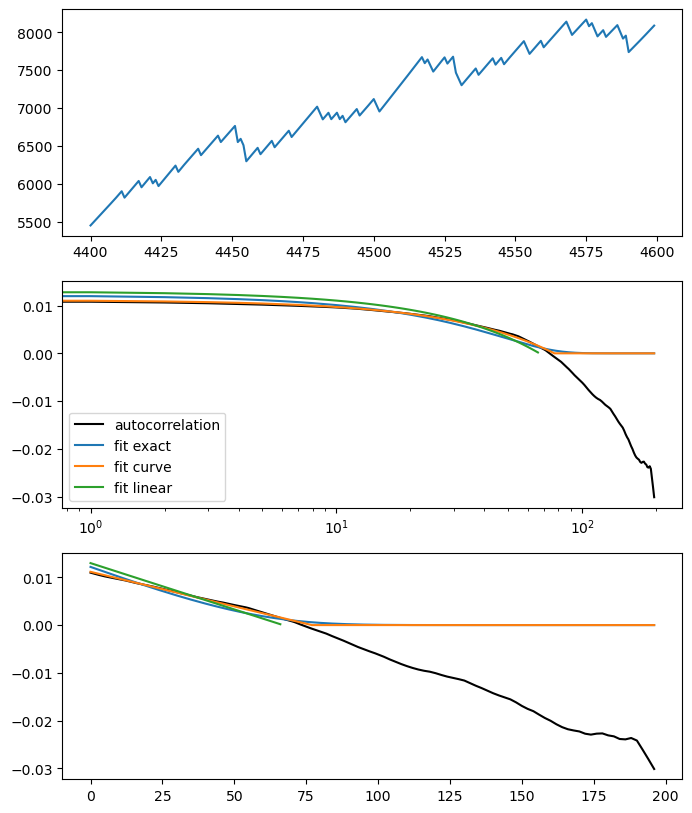

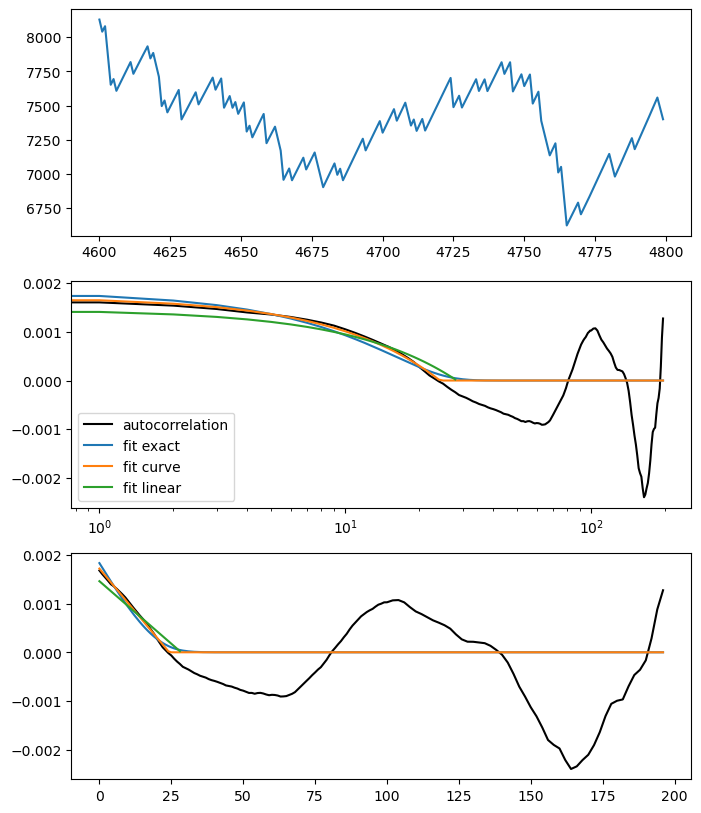

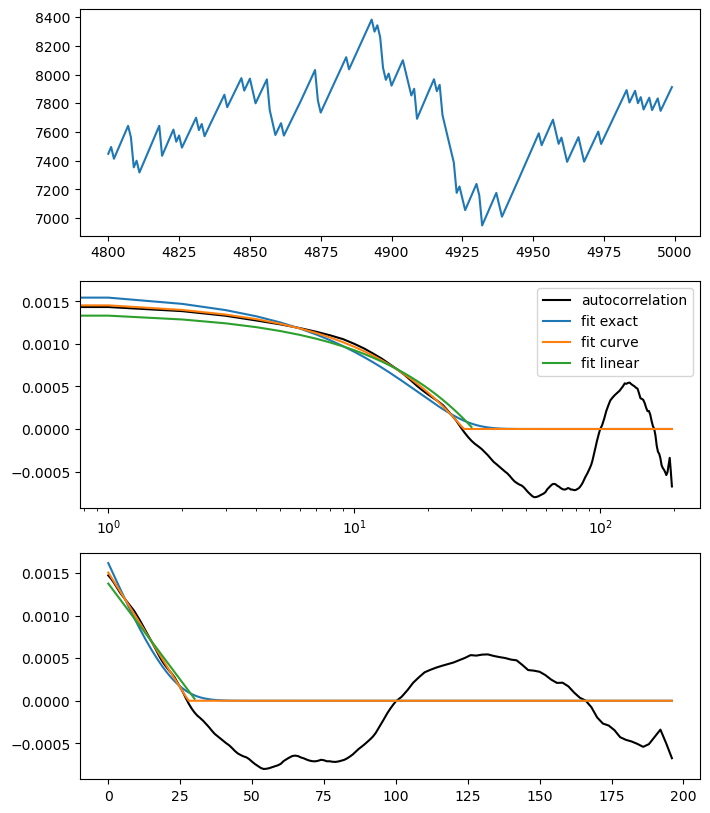

In [109]:
mins = np.arange(1000, 5000, 200)
maxs = mins+200
step = 10

datas = pd.DataFrame(columns=["start", "end", "k_curve", "c_curve", "k_linear", "c_linear","k_full", "c_full"])

for min_i, max_i in zip(mins, maxs):
    
    x_auto, y_auto = autocorrelation(y_global[::step][min_i:max_i], np.nan)
    
    x_auto, y_auto = autocorrelation(y_global[::step][min_i:max_i], 
                                    delta_t=1.)

    # analysis
    approx_k, approx_c, perr=fit_autocorrelation_approx(x_auto, y_auto, protein_size= suntag_length+prot_length)
    # print(c_elongation_r, c_translation_init_r)

    lin_k, lin_c, perr = fit_autocorrelation_linear(x_auto, y_auto, suntag_length+prot_length)
    # print(l_elongation_r, l_translation_init_r)
    
    # analysis full equation
    model = lmfit.Model(fit_function_exact)
    params = lmfit.Parameters() 
    params.add('N', value=32, vary=False)
    params.add('k', value=1, min=0)
    params.add('c', value=1, min=0)
    
    result = model.fit(y_auto, params, x=np.arange(0,len(y_auto)))
    print(result.params["c"].value, result.params["k"].value)
    print(result.params["k"].value/y_auto[0],)
    
    # print(result.params["k"], result.params["c"])

    datas = pd.concat([datas,
                         pd.DataFrame(
                             {"start": min_i,
                              "end":max_i, 
                              "k_curve": approx_k, 
                              "c_curve": approx_c, 
                              "k_linear": lin_k, 
                              "c_linear": lin_c, 
                              "k_full":result.params["k"].value, 
                              "c_full": result.params["c"].value}, index=[0])
                         ], ignore_index=True)


    fig, axes = plt.subplots(nrows=3)

    axes[0].plot(x_global[::step][min_i:max_i], 
             y_global[::step][min_i:max_i])

    axes[1].plot(x_auto, y_auto, c="black", label="autocorrelation")
    axes[1].plot(x_auto, fit_function_exact(x_auto, result.params["k"].value, result.params["c"].value, result.params["N"].value), label = "fit exact")
    axes[1].plot(x_auto, fit_function(x_auto, approx_k, approx_c)[:int(len(x_auto))], label = "fit curve")
    axes[1].plot(x_auto[:int(-lin_c/lin_k)+1], (x_auto*lin_k+lin_c)[:int(-lin_c/lin_k)+1], label = "fit linear")

    axes[2].plot(x_auto, y_auto, c="black", label="autocorrelation")
    axes[2].plot(x_auto, fit_function_exact(x_auto, result.params["k"].value, result.params["c"].value, result.params["N"].value), label = "fit exact")
    axes[2].plot(x_auto, fit_function(x_auto, approx_k, approx_c)[:int(len(x_auto))], label = "fit curve")
    axes[2].plot(x_auto[:int(-lin_c/lin_k)+1], (x_auto*lin_k+lin_c)[:int(-lin_c/lin_k)+1], label = "fit linear")
    
    axes[1].set_xscale("log")
    # ax.set_yscale("log")
    axes[1].legend()
    fig.set_size_inches((8,10))
    fig.savefig(str(min_i)+str(max_i)+".png")

In [110]:
one_loop_size = 24
datas["k_curve_calculated"] = (suntag_length)/datas["k_curve"]

datas["k_linear_calculated"] = suntag_length/(-(datas["c_linear"]/datas["k_linear"]))

datas["k_full_calculated"] = one_loop_size/(1/datas["k_full"])

In [111]:
datas.agg(["mean", "std"])

,start,end,k_curve,c_curve,k_linear,c_linear,k_full,c_full,k_curve_calculated,k_linear_calculated,k_full_calculated
mean,2900.000000,3100.000000,48.446245,13.877275,-0.000095,0.005450,0.655857,14.273180,19.307244,17.736579,15.740572
std,1183.215957,1183.215957,18.746488,14.121893,0.000098,0.006735,0.269349,14.342893,8.230359,6.861804,6.464368


In [112]:
datas.head(20)

,start,end,k_curve,c_curve,k_linear,c_linear,k_full,c_full,k_curve_calculated,k_linear_calculated,k_full_calculated
0,1000,1200,63.905728,1.933529,-0.000120,0.007933,0.432442,2.040020,12.455847,12.051827,10.378613
1,1200,1400,65.580294,1.431101,-0.000168,0.010970,0.425092,1.509972,12.137792,12.190416,10.202216
2,1400,1600,41.996714,19.753951,-0.000034,0.001298,0.680384,21.307733,18.953864,20.976023,16.329219
3,1600,1800,38.112335,4.569147,-0.000104,0.004801,0.705021,4.738285,20.885627,17.282283,16.920508
4,1800,2000,37.887928,5.626441,-0.000116,0.004580,0.722850,5.883199,21.009330,20.122217,17.348412
5,2000,2200,49.098728,6.547255,-0.000058,0.002978,0.562033,6.902927,16.212233,15.488532,13.488797
6,2200,2400,62.590961,2.275536,-0.000103,0.006823,0.435113,2.363963,12.717491,12.007584,10.442712
7,2400,2600,74.886299,10.681916,-0.000016,0.001244,0.397498,11.730405,10.629448,10.511330,9.539960
8,2600,2800,75.000300,0.539177,-0.000412,0.027369,0.378618,0.581571,10.613291,11.993510,9.086836
9,2800,3000,54.000067,10.760139,-0.000035,0.001773,0.519067,11.498527,14.740722,15.525501,12.457619


<Axes: >

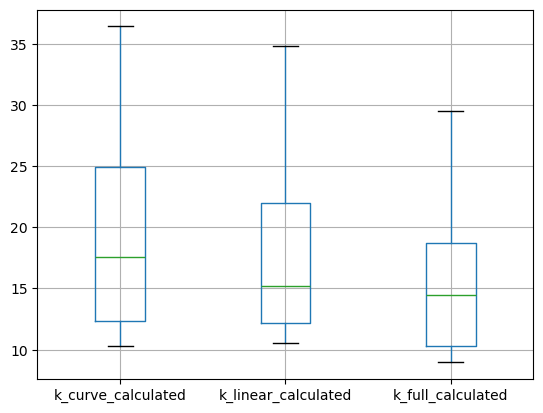

In [114]:
datas.boxplot(["k_curve_calculated","k_linear_calculated", "k_full_calculated"])

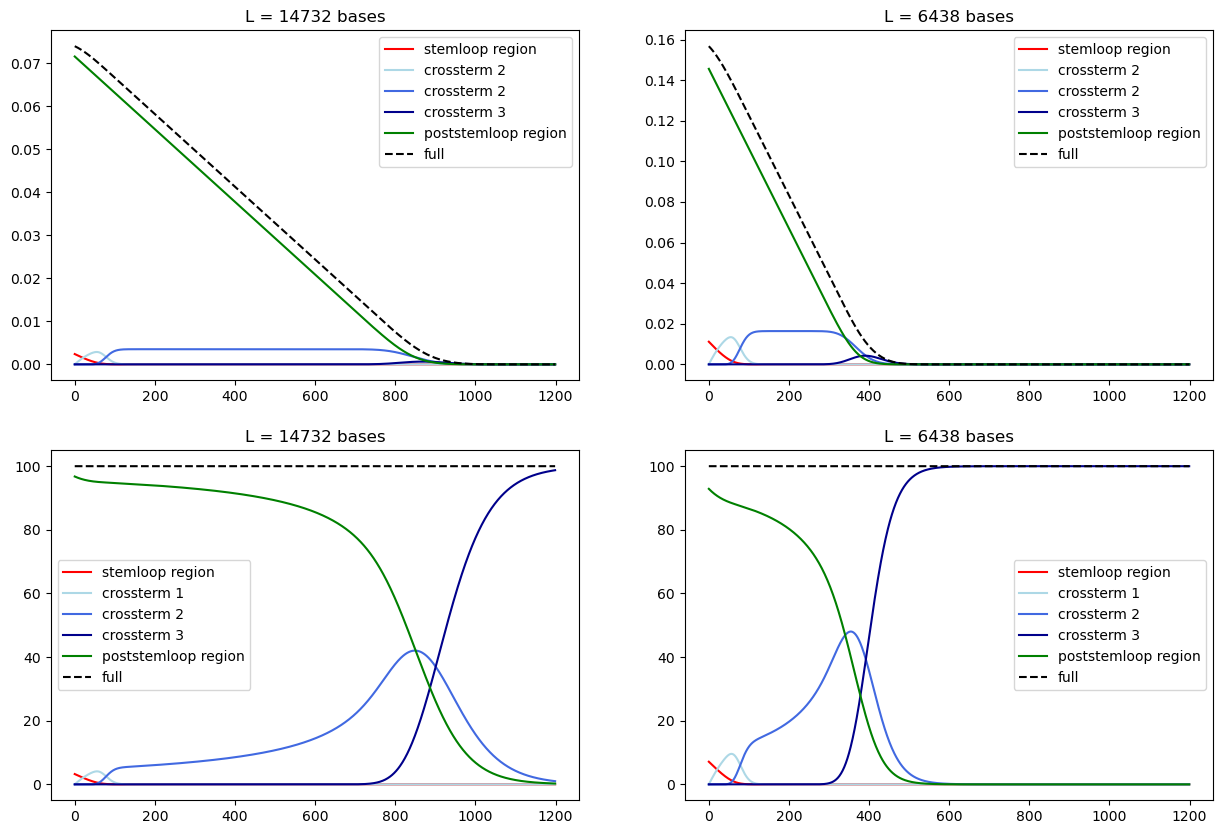

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from decimal import Decimal

#number of stem loop
N = 24
#stem loop size
s = 58
k = 0.3
c = 0.015

tau = np.arange(0, np.int64(1200))

fig, axes = plt.subplots(ncols=2, nrows = 2, sharey =False)

# gene 1
#length of gene
L = 14732
# L= 6438

i=0
for L in [14732, 6438]:

    M = L/s
    
    denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
    
    k = np.float128(0.3)
    c = np.float128(0.015)
    
    part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
    
    part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
    part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
    part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
    
    part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
    axes[0,i].plot(tau, part1, label="stemloop region", color="red")
    
    axes[0,i].plot(tau, part2, label="crossterm 2", color="lightblue")
    axes[0,i].plot(tau, part3, label="crossterm 2",  color="royalblue")
    axes[0,i].plot(tau, part4, label="crossterm 3",  color="darkblue")
    axes[0,i].plot(tau, part5, label="poststemloop region", color="green")

    axes[0,i].plot(tau, part1+part2+part3+part4+part5, '--', label="full", color="black")
    
    axes[0,i].set_title("L = " + str(L)+ " bases")
    axes[0,i].legend()


    # percentage
    axes[1,i].plot(tau, part1*100/(part1+part2+part3+part4+part5), label="stemloop region", color="red")    
    axes[1,i].plot(tau, part2*100/(part1+part2+part3+part4+part5), label="crossterm 1", color="lightblue")  
    axes[1,i].plot(tau, part3*100/(part1+part2+part3+part4+part5), label="crossterm 2",  color="royalblue")    
    axes[1,i].plot(tau, part4*100/(part1+part2+part3+part4+part5), label="crossterm 3",  color="darkblue")    
    axes[1,i].plot(tau, part5*100/(part1+part2+part3+part4+part5), label="poststemloop region", color="green")
    
    axes[1,i].plot(tau, (part1+part2+part3+part4+part5)*100/(part1+part2+part3+part4+part5), '--', label="full", color="black")
    
    axes[1,i].set_title("L = " + str(L)+ " bases")
    axes[1,i].legend()

    i+=1

fig.set_size_inches(15,10)

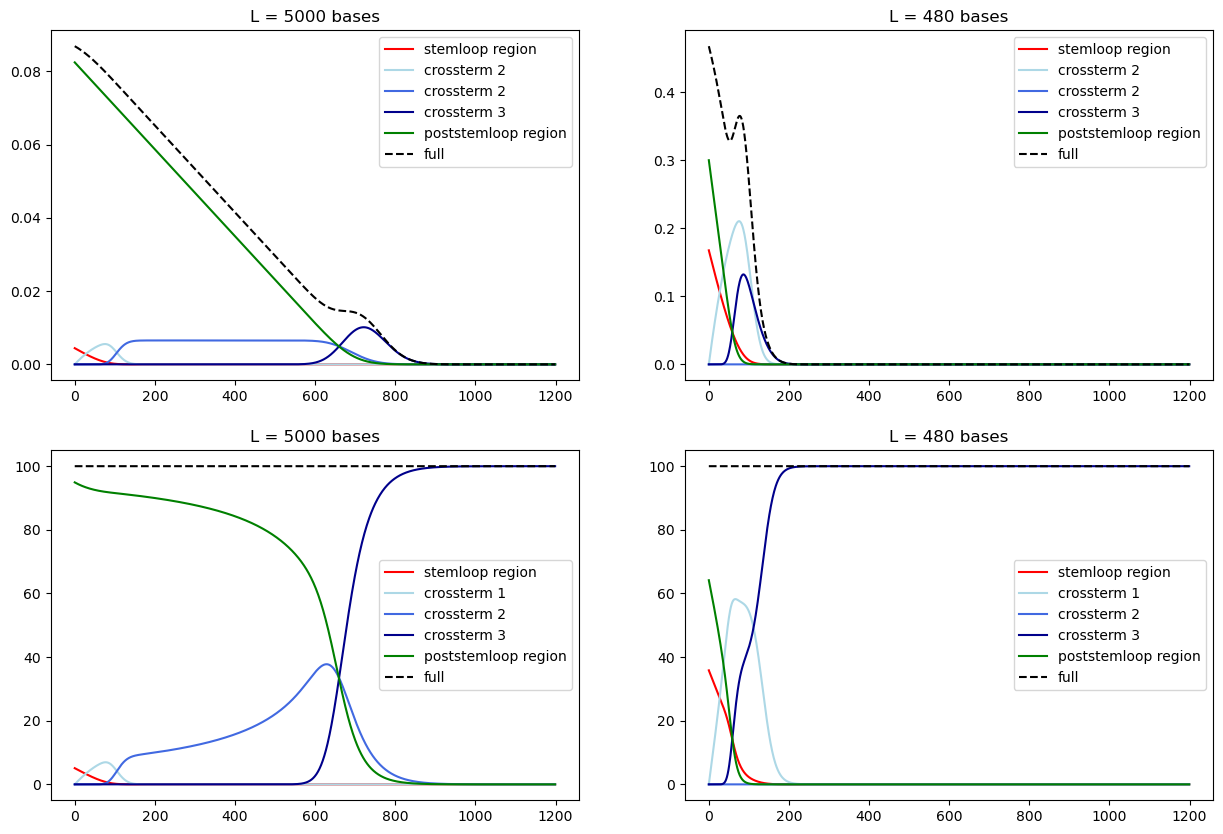

In [187]:
import numpy as np
import matplotlib.pyplot as plt
from math import factorial
from decimal import Decimal

#number of stem loop
N = 32
#stem loop size
s = 24
k = 0.3
c = 0.015

tau = np.arange(0, np.int64(1200))

fig, axes = plt.subplots(ncols=2, nrows=2, sharey =False)


i=0
for L in [5000,480]:

    M = L/s
    
    denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
    
    k = np.float128(0.3)
    c = np.float128(0.015)
    
    part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
    
    part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
    part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
    part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
    
    part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
    axes[0,i].plot(tau, part1, label="stemloop region", color="red")
    
    axes[0,i].plot(tau, part2, label="crossterm 2", color="lightblue")
    axes[0,i].plot(tau, part3, label="crossterm 2",  color="royalblue")
    axes[0,i].plot(tau, part4, label="crossterm 3",  color="darkblue")
    axes[0,i].plot(tau, part5, label="poststemloop region", color="green")

    axes[0,i].plot(tau, part1+part2+part3+part4+part5, '--', label="full", color="black")
    
    axes[0,i].set_title("L = " + str(L)+ " bases")
    axes[0,i].legend()


    # percentage
    axes[1,i].plot(tau, part1*100/(part1+part2+part3+part4+part5), label="stemloop region", color="red")    
    axes[1,i].plot(tau, part2*100/(part1+part2+part3+part4+part5), label="crossterm 1", color="lightblue")  
    axes[1,i].plot(tau, part3*100/(part1+part2+part3+part4+part5), label="crossterm 2",  color="royalblue")    
    axes[1,i].plot(tau, part4*100/(part1+part2+part3+part4+part5), label="crossterm 3",  color="darkblue")    
    axes[1,i].plot(tau, part5*100/(part1+part2+part3+part4+part5), label="poststemloop region", color="green")
    
    axes[1,i].plot(tau, (part1+part2+part3+part4+part5)*100/(part1+part2+part3+part4+part5), '--', label="full", color="black")
    
    axes[1,i].set_title("L = " + str(L)+ " bases")
    axes[1,i].legend()

    i+=1

fig.set_size_inches(15,10)

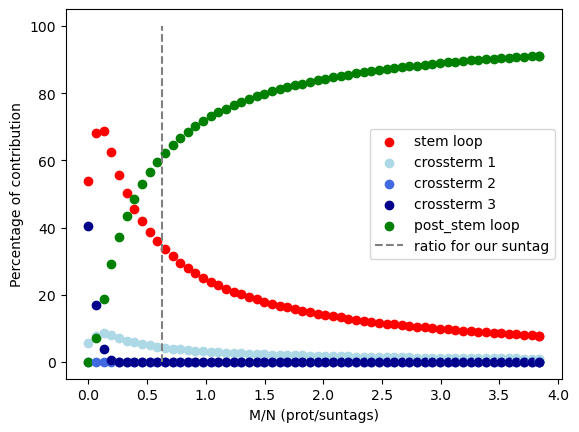

In [196]:
# estimation de la contribution de la part 1 and 5 for different ratio de prot/stemloop

tau = np.arange(0, np.int64(1200))

fig, axes = plt.subplots(ncols=1, sharey =True)

# for k in np.arange(0.1,1.5,0.2):
for L in np.arange(0,3000,50):

    M = L/s
    
    denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
    
    k = np.float128(k)
    c = np.float128(c)
    
    part1 = c/k*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
    
    part2 = c/k*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
    part3 = c/k*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
    part4 = c/k*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
    
    part5 = c/k*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator

    axes.scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red")
    axes.scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue")
    axes.scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue")
    axes.scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue")
    axes.scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green")

axes.scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red", label = "stem loop")
axes.scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue",label="crossterm 1")
axes.scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue",label="crossterm 2")
axes.scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue",label="crossterm 3")
axes.scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green", label = "post_stem loop")

# show position of suntag for us
M = 480/s
axes.vlines(M/N, 0, 100, linestyles='dashed', color='grey', label="ratio for our suntag")


axes.set_xlabel("M/N (prot/suntags)")
axes.set_ylabel("Percentage of contribution")
axes.legend()


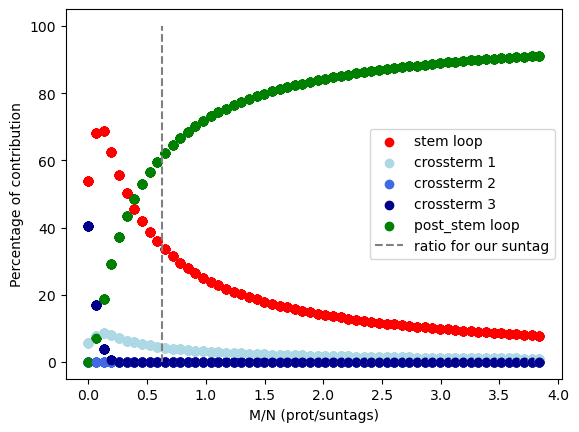

In [195]:
# estimation de la contribution de la part 1 and 5 for different ratio de prot/stemloop

#number of stem loop
N = 32
#stem loop size
s = 24
k = 0.3
c = 0.015

tau = np.arange(0, np.int64(1200))

fig, axes = plt.subplots(ncols=1, sharey =True)

for c in np.arange(0.1,10.,0.5):
    for L in np.arange(0,3000,50):
    
        M = L/s
        
        denominator= (c/k)**2*((N*(N+1))/2 + N*M)**2
        
        k = np.float128(k)
        c = np.float128(c)
        
        part1 = (c/k)*np.exp(-k*tau) * sum((N-n)*(N-n+1)*(((2*N)+n+1)/6)*(((k*tau)**n)/np.float128(factorial(n))) for n in range (0, int(N))) /denominator
        
        part2 = (c/k)*np.exp(-k*tau) * N * sum(n * ((2*N-n+1)/2) * ((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (0, int(N))) /denominator
        part3 = (c/k)*np.exp(-k*tau) * (N**2) * ((N+1)/2) * sum(((k*tau)**n)/(np.float128(factorial(int(n)))) for n in range (N, int(M))) /denominator
        part4 = (c/k)*np.exp(-k*tau) * N * sum(n *( (1+n)/2) * (((k*tau)**(M+N-n))/(np.float128(factorial(int(M+N-n))))) for n in range (1, int(N))) /denominator
        
        part5 = (c/k)*np.exp(-k*tau) * (N**2) * sum((M-n)*(((k*tau)**n)/(np.float128(factorial(int(n))))) for n in range (0, int(M))) /denominator
    
        axes.scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red")
        axes.scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue")
        axes.scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue")
        axes.scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue")
        axes.scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green")

axes.scatter(M/N, (part1*100/(part1+part2+part3+part4+part5))[:10].mean(), color="red", label = "stem loop")
axes.scatter(M/N, (part2*100/(part1+part2+part3+part4+part5))[:10].mean(), color="lightblue",label="crossterm 1")
axes.scatter(M/N, (part3*100/(part1+part2+part3+part4+part5))[:10].mean(), color="royalblue",label="crossterm 2")
axes.scatter(M/N, (part4*100/(part1+part2+part3+part4+part5))[:10].mean(), color="darkblue",label="crossterm 3")
axes.scatter(M/N, (part5*100/(part1+part2+part3+part4+part5))[:10].mean(), color="green", label = "post_stem loop")

# show position of suntag for us
M = 480/s
axes.vlines(M/N, 0, 100, linestyles='dashed', color='grey', label="ratio for our suntag")


axes.set_xlabel("M/N (prot/suntags)")
axes.set_ylabel("Percentage of contribution")
axes.legend()

In [201]:
result()

In [225]:
result.params["k"].stderr

0.16863627862709651

In [223]:
result.params["k"]

<Parameter 'k', value=0.4500733910006258 +/- 0.169, bounds=[0:inf]>